# From Bayesian Collapse to Prediction-Centric UQ

A hands-on journey through three approaches to uncertainty quantification under **model misspecification**.

**Setup:** Data comes from a *bimodal* mixture of Gaussians, but our model is a *single* Gaussian $N(\theta, 1)$. No single $\theta$ can capture the truth.

We try three things:
1. **Standard Bayes** --- the textbook approach
2. **Repulsive Ensemble** (Wild et al., NeurIPS 2023) --- adds particle diversity via Wasserstein gradient flows
3. **PCUQ via MMD** (Shen et al., AISTATS 2025) --- optimises the *mixture predictive* to match data

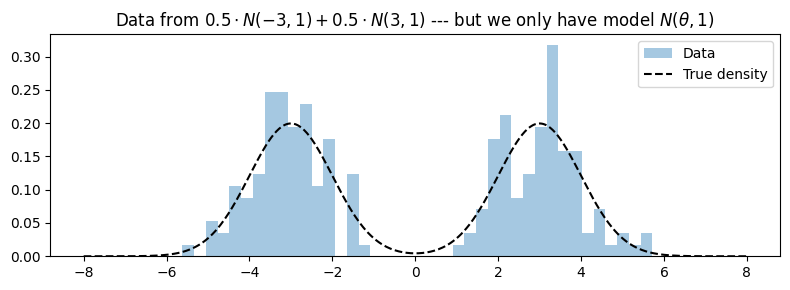

In [23]:
import torch, numpy as np, matplotlib.pyplot as plt
np.random.seed(42); torch.manual_seed(42)

# --- Bimodal data: 0.5*N(-3,1) + 0.5*N(3,1) ---
data = np.concatenate([np.random.randn(100) - 3, np.random.randn(100) + 3])
x = torch.tensor(data, dtype=torch.float32)
grid = torch.linspace(-8, 8, 500)
true_pdf = 0.5 * (torch.exp(-(grid+3)**2/2) + torch.exp(-(grid-3)**2/2)) / (2*np.pi)**0.5

def mix_pred(particles, s2=1.0):
    """Mixture predictive: (1/M) * sum_i N(grid; theta_i, s2)"""
    d = grid[:, None] - particles[None, :]
    return (torch.exp(-d**2 / (2*s2)) / (2*np.pi*s2)**0.5).mean(1)

plt.figure(figsize=(8, 3))
plt.hist(data, bins=40, density=True, alpha=0.4, label='Data')
plt.plot(grid, true_pdf, 'k--', label='True density')
plt.legend()
plt.title(r'Data from $0.5\cdot N(-3,1) + 0.5\cdot N(3,1)$ --- but we only have model $N(\theta,1)$')
plt.tight_layout()
plt.show()

## Attempt 1: Standard Bayesian Inference

With Gaussian likelihood $x_i \sim N(\theta, 1)$ and a flat prior, the posterior is analytic:
$$\theta \mid x_{1:n} \;\sim\; N\!\left(\bar{x},\; \tfrac{1}{n}\right)$$

Our bimodal data has $\bar{x} \approx 0$, so the posterior **collapses** to $\theta \approx 0$ --- right between the modes, where *no data lives*.

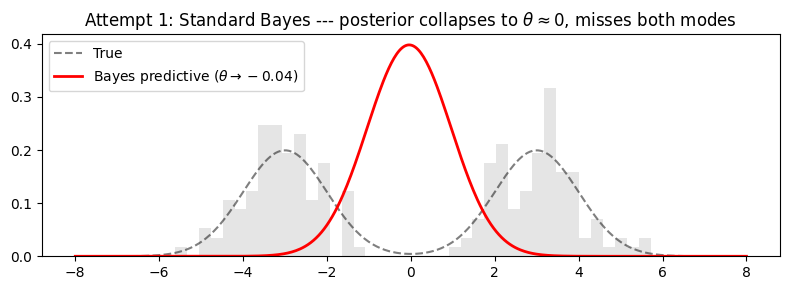

In [24]:
mu_post = x.mean().item()
s2_pred = 1.0 + 1.0 / len(x)  # posterior predictive variance
bayes_pdf = torch.exp(-(grid - mu_post)**2 / (2*s2_pred)) / (2*np.pi*s2_pred)**0.5

plt.figure(figsize=(8, 3))
plt.hist(data, bins=40, density=True, alpha=0.2, color='gray')
plt.plot(grid, true_pdf, 'k--', alpha=0.5, label='True')
plt.plot(grid, bayes_pdf, 'r-', lw=2, label=f'Bayes predictive ($\\theta \\to {mu_post:.2f}$)')
plt.legend()
plt.title('Attempt 1: Standard Bayes --- posterior collapses to $\\theta \\approx 0$, misses both modes')
plt.tight_layout()
plt.show()

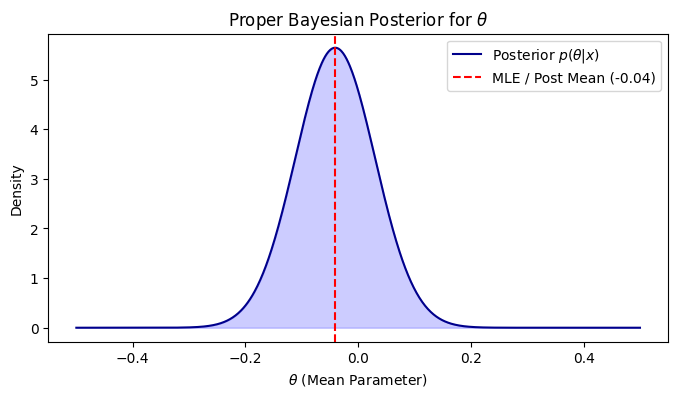

In [25]:
n = len(x)
x_bar = x.mean().item()
sigma2 = 1.0  # Assumed known variance

# The Posterior for theta: N(theta; x_bar, sigma2/n)
post_mean = x_bar
post_var = sigma2 / n
post_std = np.sqrt(post_var)

theta_grid = torch.linspace(-0.5, 0.5, 1000)
# p(theta | x) = (1 / sqrt(2 * pi * var)) * exp(-(theta - mean)^2 / (2 * var))
posterior_pdf = (1 / np.sqrt(2 * np.pi * post_var)) * \
                torch.exp(-(theta_grid - post_mean)**2 / (2 * post_var))

# Plotting the Parameter Space
plt.figure(figsize=(8, 4))
plt.plot(theta_grid, posterior_pdf, label=r'Posterior $p(\theta | x)$', color='darkblue')
plt.fill_between(theta_grid, posterior_pdf, alpha=0.2, color='blue')
plt.axvline(x_bar, color='red', linestyle='--', label=f'MLE / Post Mean ({x_bar:.2f})')

plt.title(r'Proper Bayesian Posterior for $\theta$')
plt.xlabel(r'$\theta$ (Mean Parameter)')
plt.ylabel('Density')
plt.legend()
plt.show()

> Set up with V and kernal and brownian bit -> limit distribution
do it on something specified 


without kernels first on e.g. standard normal -> how fast convergence


## Attempt 2: Repulsive Ensemble (Wild et al., 2023)

Wild et al. train an ensemble of particles $\{\theta_1, \dots, \theta_M\}$ using **Wasserstein gradient flows**. Each particle fits the data via its own log-likelihood, but an RBF kernel repulsion in *parameter space* prevents total collapse:

$$\min_{\theta_{1:M}} \;\underbrace{\frac{1}{M}\sum_i \ell(\theta_i)}_{\text{avg data fit}} \;+\; \lambda\,\underbrace{\frac{1}{M^2}\sum_{i,j} k(\theta_i, \theta_j)}_{\text{particle repulsion}}$$

**The catch:** each particle *independently* maximises its own likelihood, so they all gravitate toward $\theta \approx 0$. The repulsion spreads them out, but around the wrong centre.

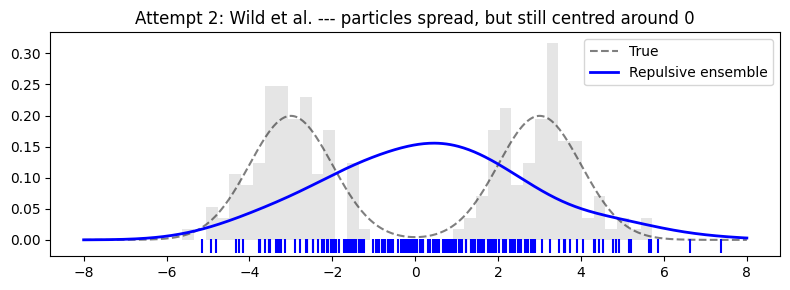

In [32]:
M = 200
init = torch.randn(M) * 3  # save for reuse
particles = init.clone().requires_grad_(True)

# Track integrated squared error vs true density
dx = (grid[1] - grid[0]).item()
def ise(p): return (dx * (mix_pred(p.detach()) - true_pdf)**2).sum().item()

losses_wild = []
for step in range(3000):
    if step % 10 == 0: losses_wild.append((step, ise(particles)))
    nll = 0.5 * ((x - particles[:, None])**2).mean()            # avg neg-log-lik
    K = torch.exp(-(particles[:, None] - particles[None, :])**2 / 2)  # RBF kernel
    loss = nll + 5.0 * K.mean()                                  # data fit + repulsion
    loss.backward()
    with torch.no_grad():
        particles -= 0.01 * particles.grad
        particles.grad.zero_()
losses_wild.append((3000, ise(particles)))

pred_wild = mix_pred(particles.detach())

plt.figure(figsize=(8, 3))
plt.hist(data, bins=40, density=True, alpha=0.2, color='gray')
plt.plot(grid, true_pdf, 'k--', alpha=0.5, label='True')
plt.plot(grid, pred_wild, 'b-', lw=2, label='Repulsive ensemble')
plt.scatter(particles.detach(), -0.01 * torch.ones(M), c='blue', marker='|', s=100, zorder=5)
plt.legend()
plt.title('Attempt 2: Wild et al. --- particles spread, but still centred around 0')
plt.tight_layout()
plt.show()

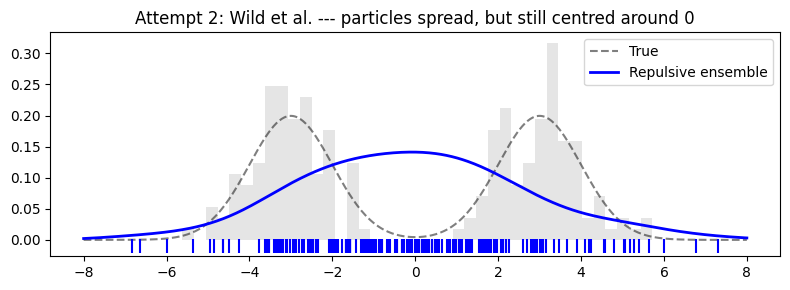

In [33]:
M = 200
init = torch.randn(M) * 3  # save for reuse
particles = init.clone().requires_grad_(True)

# Track integrated squared error vs true density
dx = (grid[1] - grid[0]).item()
def ise(p): return (dx * (mix_pred(p.detach()) - true_pdf)**2).sum().item()

losses_wild = []
for step in range(3000):
    if step % 10 == 0: losses_wild.append((step, ise(particles)))
    nll = 0.5 * ((x - particles[:, None])**2).mean()            # avg neg-log-lik
    # K = torch.exp(-(particles[:, None] - particles[None, :])**2 / 2)  # RBF kernel
    loss = nll# + 5.0 * K.mean()                                  # data fit + repulsion
    loss.backward()
    with torch.no_grad():
        particles -= 0.01 * particles.grad
        particles.grad.zero_()
losses_wild.append((3000, ise(particles)))

pred_wild = mix_pred(particles.detach())

plt.figure(figsize=(8, 3))
plt.hist(data, bins=40, density=True, alpha=0.2, color='gray')
plt.plot(grid, true_pdf, 'k--', alpha=0.5, label='True')
plt.plot(grid, pred_wild, 'b-', lw=2, label='Repulsive ensemble')
plt.scatter(particles.detach(), -0.01 * torch.ones(M), c='blue', marker='|', s=100, zorder=5)
plt.legend()
plt.title('Attempt 2: Wild et al. --- particles spread, but still centred around 0')
plt.tight_layout()
plt.show()

The repulsion adds diversity, but the predictive is still **unimodal** and centred at zero. The fundamental issue: each particle is scored on its *individual* fit, so no particle is incentivised to sit at $\theta = -3$ (poor individual fit!) even though the *mixture* would benefit.

## Attempt 3: Prediction-Centric UQ via MMD (Shen et al., 2025)

Shen et al.'s key insight: **optimise the mixture predictive directly**. Instead of scoring particles individually, measure how well the mixture $P_Q = \frac{1}{M}\sum_i N(\theta_i, 1)$ matches the data using the **MMD**:

$$\min_{\theta_{1:M}} \; \widehat{\text{MMD}}^2\!\left(P_{\text{data}},\; P_Q\right) = \underbrace{W}_{\text{self-similarity}} - 2\underbrace{V}_{\text{data fit}}$$

For Gaussian models with Gaussian kernel (bandwidth $h^2$), both terms have **closed form**:
- $V = \sqrt{\frac{h^2}{h^2+\sigma^2}} \cdot \frac{1}{NM}\sum_{j,i} \exp\!\left(-\frac{(x_j - \theta_i)^2}{2(h^2+\sigma^2)}\right)$ --- pulls particles toward data
- $W = \sqrt{\frac{h^2}{h^2+2\sigma^2}} \cdot \frac{1}{M^2}\sum_{i,k} \exp\!\left(-\frac{(\theta_i - \theta_k)^2}{2(h^2+2\sigma^2)}\right)$ --- pushes particles apart

The repulsion here isn't ad-hoc --- it emerges from the predictive objective. Particles spread because the *mixture needs them spread* to match the data.

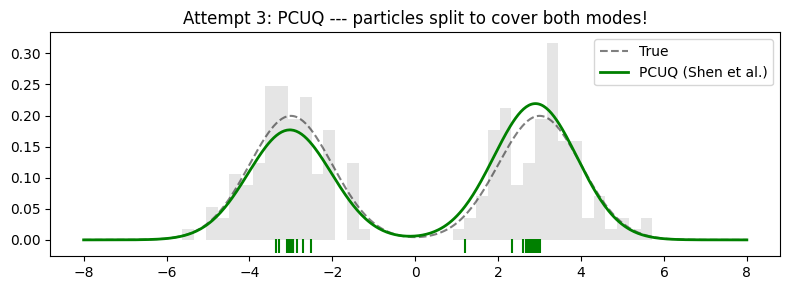

In [ ]:
h2, s2 = 2.0, 1.0  # kernel bandwidth^2, model variance
particles = init.clone().requires_grad_(True)  # same init as before

losses_pcuq = []
for step in range(3000):
    if step % 10 == 0: losses_pcuq.append((step, ise(particles)))
    # Closed-form MMD^2 between data and Gaussian mixture predictive
    s_cross, s_self = h2 + s2, h2 + 2*s2
    V = (h2/s_cross)**0.5 * torch.exp(-(x[:, None] - particles[None, :])**2 / (2*s_cross)).mean()
    # W = (h2/s_self)**0.5  * torch.exp(-(particles[:, None] - particles[None, :])**2 / (2*s_self)).mean()
    loss = len(x) * (-2*V + 0) + 0.001 * (particles**2).mean()  # scale + weak prior
    loss.backward()
    with torch.no_grad():
        particles -= 0.01 * particles.grad
        particles.grad.zero_()
losses_pcuq.append((3000, ise(particles)))

pred_pcuq = mix_pred(particles.detach())

plt.figure(figsize=(8, 3))
plt.hist(data, bins=40, density=True, alpha=0.2, color='gray')
plt.plot(grid, true_pdf, 'k--', alpha=0.5, label='True')
plt.plot(grid, pred_pcuq, 'g-', lw=2, label='PCUQ (Shen et al.)')
plt.scatter(particles.detach(), -0.01 * torch.ones(M), c='green', marker='|', s=100, zorder=5)
plt.legend(); plt.title('Attempt 3: PCUQ --- particles split to cover both modes!')
plt.tight_layout(); plt.show()

In [ ]:
h2, s2 = 2.0, 1.0  # kernel bandwidth^2, model variance
particles = init.clone().requires_grad_(True)  # same init as before

losses_pcuq = []
for step in range(3000):
    if step % 10 == 0: losses_pcuq.append((step, ise(particles)))
    # Closed-form MMD^2 between data and Gaussian mixture predictive
    s_cross, s_self = h2 + s2, h2 + 2*s2
    V = (h2/s_cross)**0.5 * torch.exp(-(x[:, None] - particles[None, :])**2 / (2*s_cross)).mean()
    W = (h2/s_self)**0.5  * torch.exp(-(particles[:, None] - particles[None, :])**2 / (2*s_self)).mean()
    loss = len(x) * (-2*V + W) + 0.001 * (particles**2).mean()  # scale + weak prior
    loss.backward()
    with torch.no_grad():
        particles -= 0.01 * particles.grad
        particles.grad.zero_()
losses_pcuq.append((3000, ise(particles)))

pred_pcuq = mix_pred(particles.detach())

plt.figure(figsize=(8, 3))
plt.hist(data, bins=40, density=True, alpha=0.2, color='gray')
plt.plot(grid, true_pdf, 'k--', alpha=0.5, label='True')
plt.plot(grid, pred_pcuq, 'g-', lw=2, label='PCUQ (Shen et al.)')
plt.scatter(particles.detach(), -0.01 * torch.ones(M), c='green', marker='|', s=100, zorder=5)
plt.legend(); plt.title('Attempt 3: PCUQ --- particles split to cover both modes!')
plt.tight_layout(); plt.show()

## Bonus: The PrO Posterior (McLatchie et al., 2025)

The **Predictively Oriented (PrO) posterior** generalises PCUQ beyond MMD to *any* proper scoring rule $S$:

$$Q_n = \arg\min_{Q} \; \frac{\lambda_n}{n} \sum_{i=1}^{n} S\!\left(\int P_\theta \, dQ(\theta),\; x_i\right) + \text{KL}(Q \| \Pi)$$

The critical difference from Gibbs posteriors: the score $S$ is applied to the **mixture predictive** $\int P_\theta\, dQ(\theta)$, not averaged over individual models. Gibbs minimises the *average of scores*; PrO minimises the *score of the average*.

**Key results:**
- **Well-specified:** PrO concentrates at the true $\theta$ at rate $\sqrt{\log n / n}$ — same as standard Bayes. No cost to using it.
- **Misspecified:** PrO does **not collapse**. It stabilises at a distribution whose spread reflects misspecification. Theorem 1: PrO *predictively dominates* Gibbs posteriors.
- **Unifies prior work:** Shen et al. (MMD), Masegosa 2020 (log score), Morningstar et al. 2022 — all special cases under one framework.

Below we use the **log scoring rule**: $S(P_Q, x) = -\log P_Q(x)$ where $P_Q = \frac{1}{M}\sum_i N(x;\theta_i, 1)$.

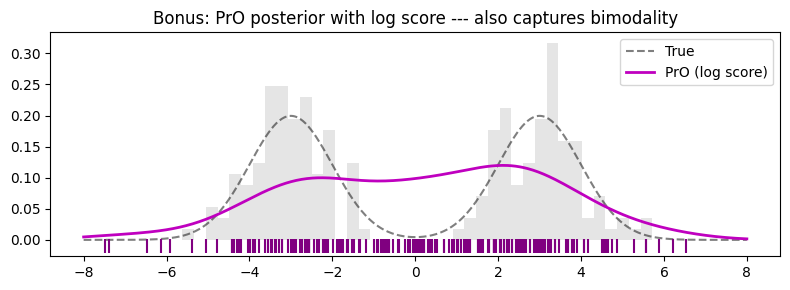

In [28]:
# PrO with log score: minimise -log P_Q(x) where P_Q = (1/M) sum_i N(x; theta_i, 1)
particles_pro = init.clone().requires_grad_(True)

losses_pro = []
for step in range(10000):
    if step % 10 == 0: losses_pro.append((step, ise(particles_pro)))
    diff = x[:, None] - particles_pro[None, :]          # (N, M)
    log_components = -0.5 * diff**2                       # log N(x;theta,1) up to const
    mix_ll = torch.logsumexp(log_components, dim=1) - np.log(M)  # log mixture density
    loss = -mix_ll.mean() + 0.001 * (particles_pro**2).mean()    # neg log score + prior
    loss.backward()
    with torch.no_grad():
        particles_pro -= 0.01 * particles_pro.grad
        particles_pro.grad.zero_()
losses_pro.append((10000, ise(particles_pro)))

pred_pro = mix_pred(particles_pro.detach())

plt.figure(figsize=(8, 3))
plt.hist(data, bins=40, density=True, alpha=0.2, color='gray')
plt.plot(grid, true_pdf, 'k--', alpha=0.5, label='True')
plt.plot(grid, pred_pro, 'm-', lw=2, label='PrO (log score)')
plt.scatter(particles_pro.detach(), -0.01 * torch.ones(M), c='purple', marker='|', s=100, zorder=5)
plt.legend(); plt.title('Bonus: PrO posterior with log score --- also captures bimodality')
plt.tight_layout(); plt.show()

## Comparison

| | Standard Bayes | Wild et al. | Shen et al. (PCUQ) | PrO (McLatchie et al.) |
|---|---|---|---|---|
| **What's optimised** | Per-parameter likelihood | Per-parameter + repulsion | Mixture-predictive MMD | Mixture-predictive (any score) |
| **Under misspecification** | Collapses to $\bar{x}$ | Spreads around $\bar{x}$ | Splits to cover modes | Splits to cover modes |
| **Predictive shape** | Unimodal at 0 | Broad, unimodal | Bimodal — matches truth | Bimodal — matches truth |

Wild et al. built the **engine** (interacting particle gradient flows); Shen et al. pointed it at the **right target** (predictive fit via MMD); McLatchie et al. showed **any proper scoring rule works** and provided the unifying theory.

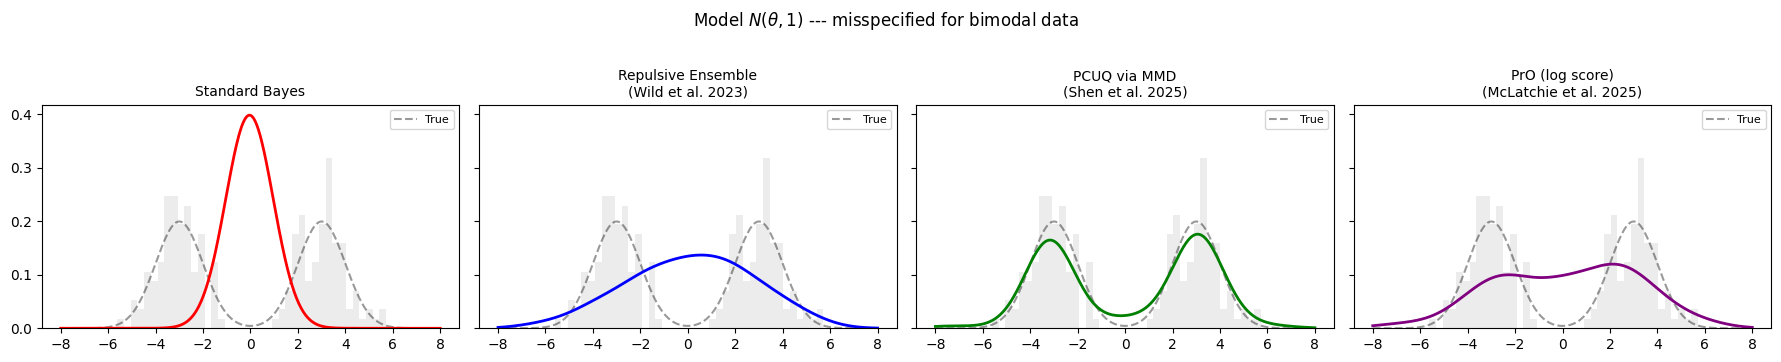

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5), sharey=True)
for ax, pdf, title, c in zip(axes,
    [bayes_pdf, pred_wild, pred_pcuq, pred_pro],
    ['Standard Bayes', 'Repulsive Ensemble\n(Wild et al. 2023)', 'PCUQ via MMD\n(Shen et al. 2025)', 'PrO (log score)\n(McLatchie et al. 2025)'],
    ['red', 'blue', 'green', 'purple']):
    ax.hist(data, bins=40, density=True, alpha=0.15, color='gray')
    ax.plot(grid.numpy(), true_pdf.numpy(), 'k--', alpha=0.4, label='True')
    ax.plot(grid.numpy(), pdf.detach().numpy(), c, lw=2)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle(r'Model $N(\theta, 1)$ --- misspecified for bimodal data', fontsize=12, y=1.02)
fig.tight_layout(); plt.show()

## Convergence: ISE vs Iteration

How quickly does each method's predictive approach the true density? We track the **Integrated Squared Error** $\int (p_{\text{pred}}(x) - p_{\text{true}}(x))^2\, dx$ every 10 steps. Standard Bayes is a constant (no training) shown as a dashed line.

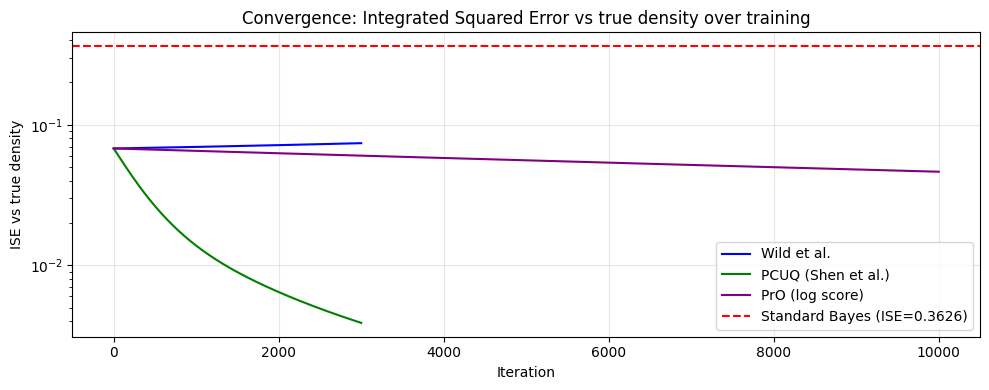

In [30]:
# Bayes ISE (constant — no training)
bayes_ise = (dx * (bayes_pdf - true_pdf)**2).sum().item()

plt.figure(figsize=(10, 4))
for trace, label, c in [(losses_wild, 'Wild et al.', 'blue'),
                         (losses_pcuq, 'PCUQ (Shen et al.)', 'green'),
                         (losses_pro, 'PrO (log score)', 'purple')]:
    steps, vals = zip(*trace)
    plt.plot(steps, vals, c=c, lw=1.5, label=label)
plt.axhline(bayes_ise, color='red', ls='--', lw=1.5, label=f'Standard Bayes (ISE={bayes_ise:.4f})')
plt.xlabel('Iteration'); plt.ylabel('ISE vs true density')
plt.yscale('log'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title('Convergence: Integrated Squared Error vs true density over training')
plt.tight_layout(); plt.show()